<a href="https://colab.research.google.com/github/azrapatvi/dl-practice/blob/main/16_Fashion_MNIST_CNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from tensorflow.keras import datasets

fashion_mnist=datasets.fashion_mnist

(train_images,train_labels),(test_images,test_labels)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
train_images

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
len(train_images)

60000

In [ ]:
len(train_labels)

60000

In [ ]:
len(test_images)

10000

In [ ]:
len(test_labels)

10000

In [ ]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']



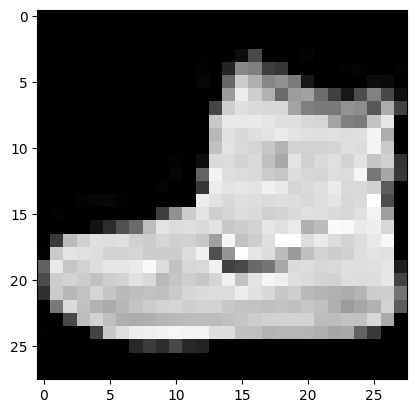

In [ ]:
plt.imshow(train_images[0],cmap='grey')
plt.show()

In [ ]:
print(train_labels[0])

9


class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

               0-9

In [ ]:
print(train_images.shape)

(60000, 28, 28)


it didnt show any channel so it means it has 1 chanel the images are in grayscale

In [ ]:
#normalize

train_images=train_images/255.0
test_images=test_images/255.0

In [ ]:
#reshape
train_images=train_images.reshape((-1,28,28,1))
test_images=test_images.reshape((-1,28,28,1))

In [ ]:
# create cnn model

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D

model=Sequential()

model.add(Conv2D(72,activation='relu',kernel_size=(3,3),padding='same',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,activation='relu',kernel_size=(3,3),padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32,activation='relu',kernel_size=(3,3),padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(64,activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 72)     │           720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 72)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        41,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,866 (311.98 KB)

 Trainable params: 79,866 (311.98 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history=model.fit(train_images,train_labels,epochs=20,validation_data=(test_images,test_labels),callbacks=[early_stop])

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8303 - loss: 0.4673 - val_accuracy: 0.8684 - val_loss: 0.3641
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8892 - loss: 0.3019 - val_accuracy: 0.8909 - val_loss: 0.3040
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9063 - loss: 0.2578 - val_accuracy: 0.8981 - val_loss: 0.2760
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9156 - loss: 0.2294 - val_accuracy: 0.9069 - val_loss: 0.2597
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9228 - loss: 0.2089 - val_accuracy: 0.9023 - val_loss: 0.2695
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9290 - loss: 0.1903 - val_accuracy: 0.9065 - val_loss: 0.2518
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9364 - loss: 0.1733 - val_accuracy: 0.9129 - val_loss: 0.2493
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9400 - loss: 0.1615 -

In [ ]:
loss,acc=model.evaluate(test_images,test_labels)

print(loss)
print(acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9194 - loss: 0.2845
0.2844877541065216
0.9193999767303467


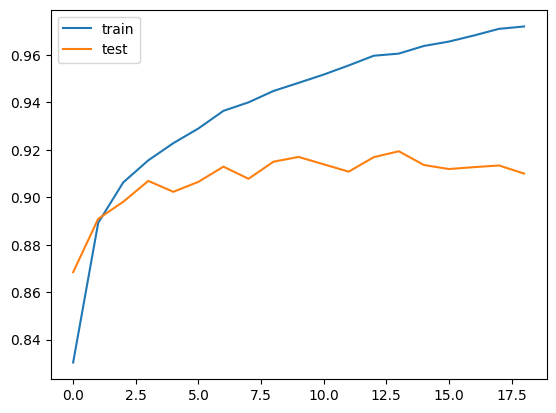

In [ ]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.legend()
plt.show()

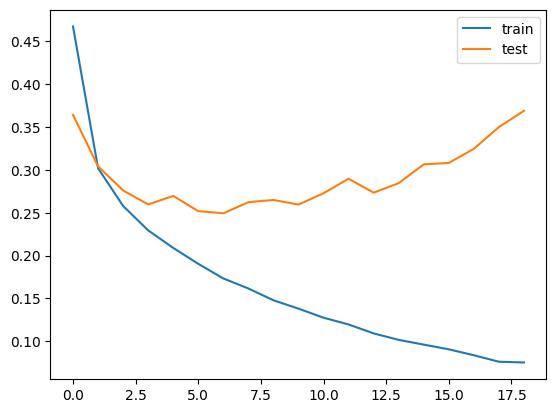

In [ ]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 12.5 MB/s eta 0:00:00


In [ ]:
def build_model(hp):

    model = Sequential()

    for i in range(hp.Int('layers', min_value=1, max_value=3)):

        model.add(
            Conv2D(
                filters=hp.Int(
                    "filters_" + str(i),
                    min_value=8,
                    max_value=128,
                    step=8
                ),
                activation='relu',
                kernel_size=(3,3),
                padding='same',
                input_shape=(28,28,1) if i == 0 else None
            )
        )

        model.add(MaxPooling2D(pool_size=(2,2)))

        model.add(
            Dropout(
                hp.Float(
                    'dropout_' + str(i),
                    min_value=0.0,
                    max_value=0.5,
                    step=0.1
                )
            )
        )

    model.add(Flatten())

    model.add(
        Dense(
            hp.Int(
                "dense_neurons",
                min_value=8,
                max_value=128,
                step=8
            ),
            activation=hp.Choice(
                'activation',
                values=['relu', 'tanh', 'sigmoid']
            )
        )
    )

    model.add(
        Dense(10, activation='softmax')
    )

    model.compile(
        optimizer=hp.Choice(
            'optimizer',
            values=['adam', 'sgd', 'rmsprop', 'adagrad']
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
import keras_tuner as kt
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='fashion_mnist_tuner',
    project_name='cnn_search',
    overwrite=True
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
tuner.search(
    train_images,
    train_labels,
    validation_data=(test_images, test_labels),
    epochs=10,
    batch_size=32
)

Trial 10 Complete [00h 01m 09s]
val_accuracy: 0.913100004196167

Best val_accuracy So Far: 0.9207000136375427
Total elapsed time: 00h 12m 34s


In [ ]:
tuner.results_summary()

Results summary
Results in fashion_mnist_tuner/cnn_search
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 06 summary
Hyperparameters:
layers: 1
filters_0: 80
dropout_0: 0.4
dense_neurons: 104
activation: sigmoid
optimizer: adam
filters_1: 88
dropout_1: 0.30000000000000004
filters_2: 72
dropout_2: 0.1
Score: 0.9207000136375427

Trial 03 summary
Hyperparameters:
layers: 3
filters_0: 80
dropout_0: 0.1
dense_neurons: 40
activation: sigmoid
optimizer: rmsprop
filters_1: 72
dropout_1: 0.4
filters_2: 80
dropout_2: 0.2
Score: 0.9154999852180481

Trial 09 summary
Hyperparameters:
layers: 1
filters_0: 8
dropout_0: 0.1
dense_neurons: 104
activation: relu
optimizer: adam
filters_1: 96
dropout_1: 0.0
filters_2: 64
dropout_2: 0.2
Score: 0.913100004196167

Trial 01 summary
Hyperparameters:
layers: 1
filters_0: 24
dropout_0: 0.0
dense_neurons: 8
activation: tanh
optimizer: adam
filters_1: 64
dropout_1: 0.30000000000000004
filters_2: 112
dropout_2: 0.4
Score: 0.90219998359

In [ ]:
tuner.get_best_hyperparameters()[0].values

{'layers': 1,
 'filters_0': 80,
 'dropout_0': 0.4,
 'dense_neurons': 104,
 'activation': 'sigmoid',
 'optimizer': 'adam',
 'filters_1': 88,
 'dropout_1': 0.30000000000000004,
 'filters_2': 72,
 'dropout_2': 0.1}

In [ ]:
n_model=tuner.get_best_models(num_models=1)[0]

In [ ]:
n_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 80)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 80)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 80)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15680)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 104)            │     1,630,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,632,674 (6.23 MB)

 Trainable params: 1,632,674 (6.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping

history = n_model.fit(
    train_images,train_labels,
    validation_data=(test_images,test_labels),
    epochs=40,
    callbacks=[early_stop]
)

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9603 - loss: 0.1116 - val_accuracy: 0.9188 - val_loss: 0.2431
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9646 - loss: 0.0992 - val_accuracy: 0.9165 - val_loss: 0.2513
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9663 - loss: 0.0942 - val_accuracy: 0.9178 - val_loss: 0.2479
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9699 - loss: 0.0856 - val_accuracy: 0.9211 - val_loss: 0.2497
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9723 - loss: 0.0790 - val_accuracy: 0.9187 - val_loss: 0.2598
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9733 - loss: 0.0743 - val_accuracy: 0.9218 - val_loss: 0.2616


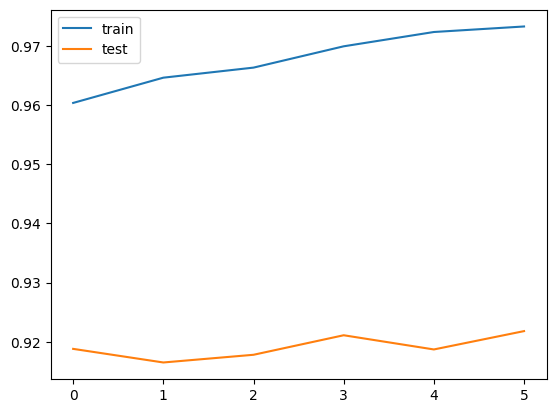

In [ ]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.legend()
plt.show()

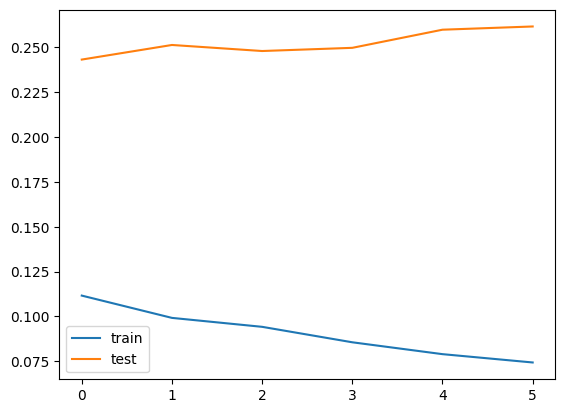

In [ ]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()